# 10-3 MNIST-CNN with Visdom

In [22]:
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torch.nn.init

# import visdom

In [23]:
import visdom

vis = visdom.Visdom()
vis.close(env="main")

Setting up a new session...


''

## define loss_tracker

In [24]:
def loss_tracker(loss_plot, loss_value, num):
    '''num, loss_value, are Tensor'''
    vis.line(X=num,
             Y=loss_value,
             win = loss_plot,
             update='append'
             )

In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(777)
if device =='cuda':
    torch.cuda.manual_seed_all(777)

In [26]:
#parameters
learning_rate = 0.001
training_epochs = 15
batch_size = 32

In [27]:
#MNIST dataset

mnist_train = dsets.MNIST(root='MNIST_data/',
                         train = True,
                         transform=transforms.ToTensor(),
                         download=True)

mnist_test = dsets.MNIST(root='MNIST_data/',
                        train=False,
                        transform = transforms.ToTensor(),
                        download=True)

In [28]:
data_loader = torch.utils.data.DataLoader(dataset=mnist_train,
                                          batch_size = batch_size,
                                          shuffle =True,
                                          drop_last=True)

In [29]:
class CNN(nn.Module):
    
    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1,8,kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(8,16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Linear(7*7*16, 10)
        self.relu = nn.ReLU()
        torch.nn.init.xavier_uniform_(self.fc.weight)
    
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)        
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out
            

In [30]:
model = CNN().to(device)

value = (torch.Tensor(1,1,28,28)).to(device)
print( (model(value)).shape ) 

torch.Size([1, 10])


In [31]:
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

## make plot

In [32]:
loss_plt = vis.line(Y=torch.Tensor(1).zero_(),opts=dict(title='loss_tracker', legend=['loss'], showlegend=True))

## train with loss_tracker

In [33]:
#training
total_batch = len(data_loader)

for epoch in range(training_epochs):
    avg_cost = 0
    
    for X, Y in data_loader:
        X = X.to(device)
        Y = Y.to(device)
        
        optimizer.zero_grad()
        hypothesis = model(X)
        
        cost = criterion(hypothesis, Y)
        cost.backward()
        optimizer.step()
        
        avg_cost += cost / total_batch
    
    print('[Epoch:{}] cost = {}'.format(epoch+1, avg_cost))
    loss_tracker(loss_plt, torch.Tensor([avg_cost]), torch.Tensor([epoch]))
print('Learning Finished!')

[Epoch:1] cost = 0.24476221203804016
[Epoch:2] cost = 0.0868724063038826
[Epoch:3] cost = 0.06662801653146744
[Epoch:4] cost = 0.05470089986920357
[Epoch:5] cost = 0.04711943492293358
[Epoch:6] cost = 0.0413372740149498
[Epoch:7] cost = 0.03764639422297478
[Epoch:8] cost = 0.03297160938382149
[Epoch:9] cost = 0.03016778640449047
[Epoch:10] cost = 0.028008852154016495
[Epoch:11] cost = 0.02511781081557274
[Epoch:12] cost = 0.023215346038341522
[Epoch:13] cost = 0.021748408675193787
[Epoch:14] cost = 0.019637612625956535
[Epoch:15] cost = 0.018506454303860664
Learning Finished!


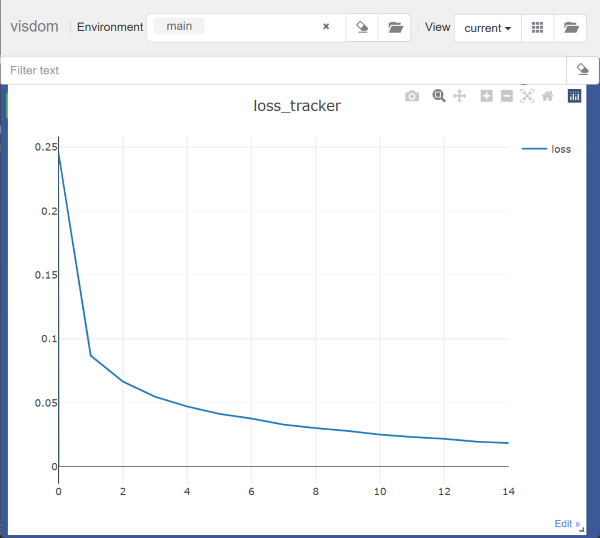

In [34]:
with torch.no_grad():
    X_test = mnist_test.data.view(len(mnist_test), 1, 28, 28).float().to(device)
    Y_test = mnist_test.targets.to(device)
    
    prediction = model(X_test)
    correct_prediction = torch.argmax(prediction, 1) == Y_test
    accuracy = correct_prediction.float().mean() 
    print('Accuracy:', accuracy.item())

Accuracy: 0.9865000247955322
